# The Ising Model: From Physics to Computation

The **Ising model** is one of the most important models in statistical physics and forms the foundation of many machine learning techniques (Boltzmann machines, QUBO optimization, etc.).

This notebook covers:
- The Ising energy function and its physical interpretation
- The high-level `ising_sample` convenience API
- Computing physical observables (magnetization, susceptibility, correlations) from samples
- Spin glasses and frustration
- The connection between Ising models and Boltzmann machines


## The Ising model

The Ising model assigns an energy to configurations of binary spins $s_i \in \{-1, +1\}$:

$$E(s) = -\beta \left( \sum_i b_i s_i + \sum_{(i,j)} J_{ij} s_i s_j \right)$$

where:
- $b_i$ is the **bias** (external field) on spin $i$
- $J_{ij}$ is the **coupling** between spins $i$ and $j$
- $\beta$ is the **inverse temperature**

**Physical interpretation:**
- Each $s_i$ represents a magnetic moment (think of an atom's spin direction)
- $J_{ij} > 0$ (ferromagnetic): neighbors prefer to align
- $J_{ij} < 0$ (antiferromagnetic): neighbors prefer to anti-align
- $b_i$ represents an external magnetic field

**Historical notes:** Proposed by Lenz (1920), solved in 1D by Ising (1925), solved exactly in 2D by Onsager (1944). In 2024, John Hopfield and Geoffrey Hinton were awarded the Nobel Prize in Physics for foundational discoveries related to the Ising model's connection to neural networks and machine learning.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

## The easy way: `ising_sample`

hamon provides `ising_sample`, a high-level function that handles the entire pipeline (graph coloring, chain-count discovery, adaptive parallel tempering, and final sampling) from just arrays of biases, edges, and weights.

In [2]:
from hamon.models.ising import ising_sample

# Build a 15x15 ferromagnetic Ising model
ROWS, COLS = 15, 15
N = ROWS * COLS

# Edges: nearest-neighbor on the grid
edge_list = []
for r in range(ROWS):
    for c in range(COLS):
        idx = r * COLS + c
        if c + 1 < COLS:
            edge_list.append([idx, idx + 1])
        if r + 1 < ROWS:
            edge_list.append([idx, idx + COLS])

edges = jnp.array(edge_list)
biases = jnp.zeros(N)
weights = jnp.ones(len(edge_list))  # uniform ferromagnetic coupling

key = jax.random.key(42)
samples, diagnostics = ising_sample(
    biases,
    edges,
    weights,
    key=key,
    beta=0.5,
    n_samples=1000,
    n_warmup=500,
)

print(f"Samples shape: {samples.shape}")
print(f"Number of chains used: {diagnostics['n_chains']}")
print(f"Communication barrier Λ: {diagnostics['Lambda']:.3f}")
print(f"Convergence: {diagnostics['converged_reason']}")

All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.


Samples shape: (1000, 225)
Number of chains used: 113
Communication barrier Λ: 96.000
Convergence: max_iters


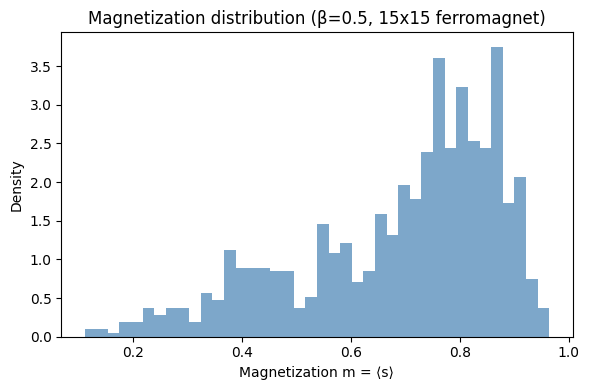

In [3]:
# Visualize magnetization distribution
spin_vals = 2 * samples.astype(jnp.float32) - 1
magnetization = jnp.mean(spin_vals, axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.array(magnetization), bins=40, density=True, alpha=0.7, color="steelblue")
ax.set_xlabel("Magnetization m = ⟨s⟩")
ax.set_ylabel("Density")
ax.set_title("Magnetization distribution (β=0.5, 15x15 ferromagnet)")
plt.tight_layout()
plt.show()

## Physical observables from samples

The power of sampling is that we can estimate **any** function of the configuration by averaging over samples. Key physical observables:

- **Magnetization**: $m = \frac{1}{N} \sum_i \langle s_i \rangle$
- **Magnetic susceptibility**: $\chi = \frac{\beta}{N} \text{Var}(M)$ where $M = \sum_i s_i$
- **Correlation function**: $C(r) = \langle s_i s_j \rangle$ for pairs at distance $r$

In [4]:
def compute_observables(samples, beta, rows, cols):
    """Compute magnetization, susceptibility, and spatial correlation function."""
    spin_vals = 2 * samples.astype(jnp.float32) - 1
    N = rows * cols

    # Magnetization (absolute value to handle symmetry breaking)
    M = jnp.sum(spin_vals, axis=1)
    m = float(jnp.mean(jnp.abs(M))) / N

    # Susceptibility
    chi = float(beta * jnp.var(M) / N)

    # Spatial correlation function C(r) for horizontal pairs
    max_r = cols // 2
    C_r = []
    for r in range(1, max_r + 1):
        corr_pairs = []
        for row in range(rows):
            for col in range(cols - r):
                i = row * cols + col
                j = row * cols + col + r
                corr_pairs.append(spin_vals[:, i] * spin_vals[:, j])
        C_r.append(float(jnp.mean(jnp.stack(corr_pairs))))

    return m, chi, C_r


m, chi, C_r = compute_observables(samples, 0.5, ROWS, COLS)
print(f"Magnetization |m| = {m:.4f}")
print(f"Susceptibility χ = {chi:.4f}")

Magnetization |m| = 0.6882
Susceptibility χ = 3.8428


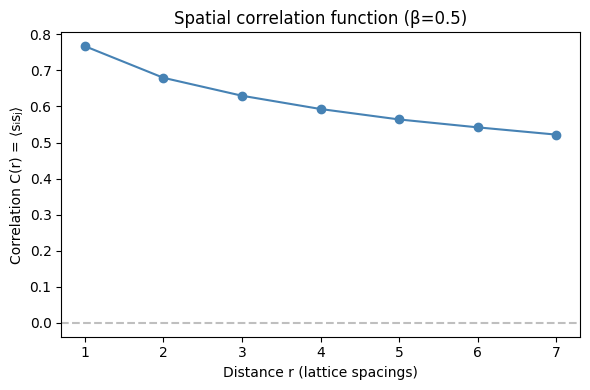

In [5]:
# Plot correlation function
fig, ax = plt.subplots(figsize=(6, 4))
distances = list(range(1, len(C_r) + 1))
ax.plot(distances, C_r, "o-", color="steelblue", markersize=6)
ax.set_xlabel("Distance r (lattice spacings)")
ax.set_ylabel("Correlation C(r) = ⟨sᵢsⱼ⟩")
ax.set_title("Spatial correlation function (β=0.5)")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.
All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.
All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.
All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.
All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.
All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.
All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.
All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.
All biases are identical (spread = 0). T

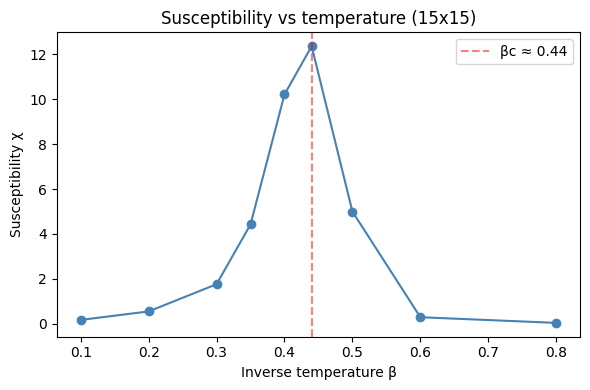

In [6]:
# Susceptibility vs temperature
beta_values = [0.1, 0.2, 0.3, 0.35, 0.4, 0.44, 0.5, 0.6, 0.8]
chis = []

for b_val in beta_values:
    key, subkey = jax.random.split(key)
    samp_b, _ = ising_sample(
        biases,
        edges,
        weights,
        key=subkey,
        beta=b_val,
        n_samples=500,
        n_warmup=300,
    )
    _, chi_b, _ = compute_observables(samp_b, b_val, ROWS, COLS)
    chis.append(chi_b)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(beta_values, chis, "o-", color="steelblue", markersize=6)
ax.axvline(0.4407, color="red", linestyle="--", alpha=0.5, label="βc ≈ 0.44")
ax.set_xlabel("Inverse temperature β")
ax.set_ylabel("Susceptibility χ")
ax.set_title("Susceptibility vs temperature (15x15)")
ax.legend()
plt.tight_layout()
plt.show()

The susceptibility peaks near the critical temperature $\beta_c \approx 0.44$, signaling the phase transition between ordered and disordered phases. This peak becomes sharper and taller for larger systems.

## Building the model manually

Under the hood, `ising_sample` creates `SpinNode`s, an `IsingEBM`, and an `IsingSamplingProgram`. Let's do this explicitly, which gives us more control — for example, we can use non-uniform couplings.

In [7]:
from hamon import SpinNode, Block, BlockGibbsSpec
from hamon.models.ising import IsingEBM, IsingSamplingProgram
import networkx as nx

# Create nodes and build the model manually
spin_nodes = [SpinNode() for _ in range(N)]
node_edges = [(spin_nodes[int(e[0])], spin_nodes[int(e[1])]) for e in edges]

# Random couplings: spin glass!
key, subkey = jax.random.split(key)
random_weights = jax.random.normal(subkey, shape=(len(node_edges),))

ebm_manual = IsingEBM(spin_nodes, node_edges, biases, random_weights, jnp.array(0.5))

# Verify energy computation: compare to manual numpy calculation
key, subkey = jax.random.split(key)
test_config = jax.random.bernoulli(subkey, shape=(N,))
test_spins = 2 * test_config.astype(jnp.float32) - 1

# Manual energy
E_bias = -0.5 * jnp.sum(biases * test_spins)
E_coupling = -0.5 * jnp.sum(
    random_weights * test_spins[edges[:, 0]] * test_spins[edges[:, 1]]
)
E_manual = E_bias + E_coupling

all_block = Block(spin_nodes)
temp_spec = BlockGibbsSpec([all_block], [])
E_hamon = ebm_manual.energy([test_config], temp_spec)

print(f"Manual energy:  {float(E_manual):.6f}")
print(f"hamon energy:   {float(E_hamon):.6f}")
print(f"Match: {jnp.allclose(E_manual, E_hamon, atol=1e-4)}")

Manual energy:  10.123622
hamon energy:   10.123622
Match: True


## Spin glasses: disorder and frustration

When the couplings $J_{ij}$ are random (positive and negative), we get a **spin glass** – a system with **frustration**. Consider a triangle with antiferromagnetic couplings ($J < 0$):

- If spins 1 and 2 are anti-aligned: $s_1 = +1, s_2 = -1$
- Spin 3 wants to anti-align with both, but that's impossible!

Frustration leads to a complex energy landscape with many local minima – exactly the scenario where advanced sampling methods like parallel tempering (Notebook 05) are needed.

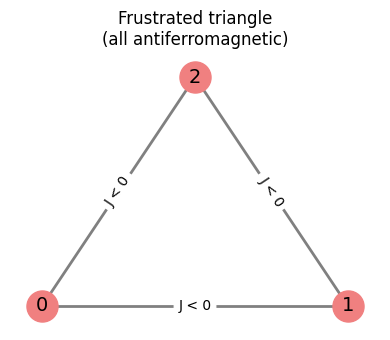

In [8]:
# Demonstrate frustration on a triangle
fig, ax = plt.subplots(figsize=(4, 3.5))

# Draw triangle
tri_pos = {0: (0, 0), 1: (2, 0), 2: (1, 1.7)}
G_tri = nx.Graph()
G_tri.add_edges_from([(0, 1), (1, 2), (0, 2)])
nx.draw(
    G_tri,
    tri_pos,
    ax=ax,
    with_labels=True,
    node_color="lightcoral",
    node_size=500,
    font_size=14,
    edge_color="gray",
    width=2,
)

# Label edges with J < 0
edge_labels = {(0, 1): "J < 0", (1, 2): "J < 0", (0, 2): "J < 0"}
nx.draw_networkx_edge_labels(G_tri, tri_pos, edge_labels, ax=ax, font_size=10)
ax.set_title("Frustrated triangle\n(all antiferromagnetic)", fontsize=12)
plt.tight_layout()
plt.show()

All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.
All biases are identical (spread = 0). The model has no per-variable preference; sampling results may be uninformative.


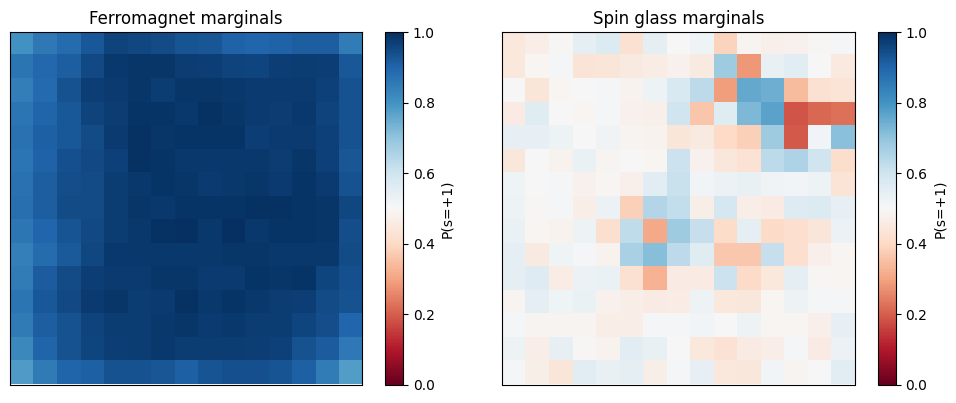

Ferromagnet: marginal std = 0.0443
Spin glass:  marginal std = 0.0844


In [9]:
# Compare: ferromagnet vs spin glass on a 15x15 lattice
key, k1, k2 = jax.random.split(key, 3)

# Ferromagnet: all J = +1
samp_ferro, _ = ising_sample(
    biases,
    edges,
    jnp.ones(len(edge_list)),
    key=k1,
    beta=0.6,
    n_samples=500,
    n_warmup=300,
)

# Spin glass: random J ~ N(0, 1)
key, k_w = jax.random.split(key)
sg_weights = jax.random.normal(k_w, shape=(len(edge_list),))
samp_glass, _ = ising_sample(
    biases,
    edges,
    sg_weights,
    key=k2,
    beta=0.6,
    n_samples=500,
    n_warmup=300,
)

# Compare marginals
marg_ferro = jnp.mean(samp_ferro.astype(jnp.float32), axis=0)
marg_glass = jnp.mean(samp_glass.astype(jnp.float32), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(marg_ferro.reshape(ROWS, COLS), cmap="RdBu", vmin=0, vmax=1)
axes[0].set_title("Ferromagnet marginals")
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(im0, ax=axes[0], label="P(s=+1)")

im1 = axes[1].imshow(marg_glass.reshape(ROWS, COLS), cmap="RdBu", vmin=0, vmax=1)
axes[1].set_title("Spin glass marginals")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(im1, ax=axes[1], label="P(s=+1)")

plt.tight_layout()
plt.show()

print(f"Ferromagnet: marginal std = {float(jnp.std(marg_ferro)):.4f}")
print(f"Spin glass:  marginal std = {float(jnp.std(marg_glass)):.4f}")

The ferromagnet shows strong global ordering (marginals far from 0.5), while the spin glass has heterogeneous marginals — some spins are strongly biased by their random local environment, but there's no global order. Sampling spin glasses accurately is challenging and motivates the parallel tempering methods we'll cover in Notebook 05.

## From Ising to Boltzmann machines

A **Restricted Boltzmann Machine (RBM)** is simply an Ising model with a special structure:

- Spins are divided into **visible** units $v$ and **hidden** units $h$
- Couplings exist only between visible and hidden (no visible-visible or hidden-hidden edges)
- This bipartite structure means we can sample all visible units in parallel given the hidden, and vice versa â€” a natural 2-block Gibbs scheme

The energy function is:

$$E(v, h) = -\left( \sum_i b_i v_i + \sum_j c_j h_j + \sum_{i,j} W_{ij} v_i h_j \right)$$

This is exactly the Ising model energy with biases $b_i, c_j$ and couplings $W_{ij}$, just with the bipartite constraint on which edges exist.

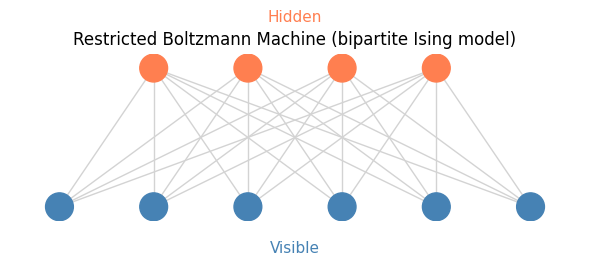

RBM: 6 visible, 4 hidden, 24 connections
2-block Gibbs: sample all visible | hidden, then all hidden | visible


In [10]:
# Build a small RBM as an IsingEBM
n_visible, n_hidden = 6, 4
n_total = n_visible + n_hidden

rbm_nodes = [SpinNode() for _ in range(n_total)]
visible_nodes = rbm_nodes[:n_visible]
hidden_nodes = rbm_nodes[n_visible:]

# Bipartite edges: every visible connects to every hidden
rbm_edges = [
    (visible_nodes[i], hidden_nodes[j])
    for i in range(n_visible)
    for j in range(n_hidden)
]

key, subkey = jax.random.split(key)
rbm_biases = jnp.zeros(n_total)
rbm_weights = jax.random.normal(subkey, shape=(len(rbm_edges),)) * 0.5

rbm_ebm = IsingEBM(rbm_nodes, rbm_edges, rbm_biases, rbm_weights, jnp.array(1.0))

# The bipartite structure means 2-coloring = visible/hidden
free_blocks_rbm = [Block(visible_nodes), Block(hidden_nodes)]
program_rbm = IsingSamplingProgram(rbm_ebm, free_blocks_rbm, [])

# Visualize the bipartite graph
G_rbm = nx.Graph()
G_rbm.add_nodes_from(range(n_visible), bipartite=0)
G_rbm.add_nodes_from(range(n_visible, n_total), bipartite=1)
for i in range(n_visible):
    for j in range(n_hidden):
        G_rbm.add_edge(i, n_visible + j)

pos_rbm = {}
for i in range(n_visible):
    pos_rbm[i] = (i, 0)
for j in range(n_hidden):
    pos_rbm[n_visible + j] = (j + 1, 1.5)

fig, ax = plt.subplots(figsize=(6, 3))
colors_rbm = ["steelblue"] * n_visible + ["coral"] * n_hidden
nx.draw(
    G_rbm,
    pos_rbm,
    ax=ax,
    node_color=colors_rbm,
    node_size=400,
    with_labels=False,
    edge_color="lightgray",
    width=1,
)
ax.text(2.5, -0.5, "Visible", ha="center", fontsize=11, color="steelblue")
ax.text(2.5, 2.0, "Hidden", ha="center", fontsize=11, color="coral")
ax.set_title("Restricted Boltzmann Machine (bipartite Ising model)")
plt.tight_layout()
plt.show()

print(f"RBM: {n_visible} visible, {n_hidden} hidden, {len(rbm_edges)} connections")
print("2-block Gibbs: sample all visible | hidden, then all hidden | visible")

Training RBMs to learn data distributions is covered in Notebook 06.

## Summary

- The **Ising model** is the canonical discrete EBM: binary spins with pairwise interactions
- `ising_sample` provides a **one-line** interface that handles graph coloring, chain discovery, and adaptive parallel tempering automatically
- Physical **observables** (magnetization, susceptibility, correlations) are easily estimated by averaging over samples
- **Spin glasses** (random couplings) create frustrated energy landscapes that challenge simple samplers
- **RBMs** are bipartite Ising models — the bridge between physics and machine learning

Next: we'll see how to build **custom probabilistic graphical models** with mixed node types, custom samplers, and observers.